In [32]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df, model_wide_accuracy_df, question_wide_accuracy_df, firac_order, model_order = read_model_runs('../data/processed/model-runs')

# Filtrar apenas as linhas em português
question_long_df = question_long_df[question_long_df["language"] == "portuguese"].copy()

print('shape', question_long_df.shape)
print('# unique questions', question_long_df['question_id'].nunique())
print('firac_order', firac_order)
print('model_order', model_order)

question_long_df = question_long_df[
    question_long_df["model_name"].str.contains("gemma", case=False, na=False) &
    ~question_long_df["model_name"].str.contains("gemma-3n-", case=False, na=False)
]

question_long_df = question_long_df[question_long_df["firac"].ne("F____")]
#question_long_df = question_long_df[question_long_df["firac"].ne("unstructured")]
#question_long_df = question_long_df.dropna()

question_long_df.head(1)

question_long_df[question_long_df.materia == 'FILOSOFIA'].head()


shape (70687, 30)
# unique questions 3230
firac_order ['FILA_', 'FIR__', 'FI___', 'FIL__', 'F____', '_____', 'unstructured']
model_order ['gemini-2.0-flash-lite', 'gemini-2.5-flash-lite', 'gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3n-e4b-it', 'gemma-3n-e2b-it', 'gemma-3-4b-it']


,model_name,firac,language,is_correct,pdf_filename,question_id,materia,oab_test_id,oab_question_id,chosen_option,...,D,full_response,Facts,Issue,Rule,Application,Conclusion,rule_count,fact_count,response_time_seconds
2775,gemma-3-12b-it,FILA_,portuguese,True,oab-40.pdf,oab-40.pdf-006,FILOSOFIA,XII,6,C,...,"convencionalismo, materialismo e fatalismo.","{\n ""F"": ""O utilitarismo é uma filosofia moder...",O utilitarismo é uma filosofia moderna que con...,Quais são as principais características da fil...,"Utilitarismo, Convencionalismo (no Utilitarism...",O utilitarismo é uma doutrina filosófica cujo ...,"A alternativa correta é a C, pois o utilitaris...",4,0,9.352558
2776,gemma-3-12b-it,FILA_,portuguese,True,oab-40.pdf,oab-40.pdf-010,FILOSOFIA,X,10,B,...,Direito e moral são absolutamente distintos. C...,"{\n ""F"":[\n ""Manter os próprios compromissos ...",['Manter os próprios compromissos constitui um...,Qual é a relação correta entre o direito e a m...,"FERRAZ JUNIOR, Tércio Sampaio. Introdução ao E...","A vontade do indivíduo, enquanto não externali...",NaN,1,4,24.658141
2777,gemma-3-12b-it,FILA_,portuguese,True,oab-40.pdf,oab-40.pdf-003,FILOSOFIA,XIII,3,B,...,"A opinião pública, o parlamento e as cortes su...","{\n ""F"":[\n ""A questão jurídica aborda a teor...","[""A questão jurídica aborda a teoria da argume...",Quais são os três auditórios que uma decisão j...,"Chaïm Perelman, Lógica Jurídica",O raciocínio judiciário deve ser ajustado de a...,NaN,1,2,6.248541
2778,gemma-3-12b-it,FILA_,portuguese,True,oab-41.pdf,oab-41.pdf-014,FILOSOFIA,XVI,14,A,...,O Direito resulta da ação institucional do Est...,"{\n ""F"":[\n ""Rudolf Von Ihering, na obra 'A L...","[""Rudolf Von Ihering, na obra 'A Luta pelo Dir...",Qual é a interpretação e o significado da afir...,"Teoria de Rudolf von Ihering, Teoria do Espíri...",A frase de Ihering é interpretada no sentido d...,NaN,4,1,8.445340
2779,gemma-3-12b-it,FILA_,portuguese,True,oab-40.pdf,oab-40.pdf-011,FILOSOFIA,XV,11,C,...,Age como se a máxima de tua ação se devesse to...,"{\n ""F"":[\n ""Na Doutrina do Direito, busca-se...","['Na Doutrina do Direito, busca-se um conceito...",Qual é a formulação da lei universal do direit...,Lei da Humanidade (Imperativo Categórico de Ka...,Ao analisar as diferentes formulações apresent...,NaN,4,4,24.026016


In [33]:
question_long_df['question_id'].nunique()

3230

In [34]:
import json

def count_source(row):
    rule_dict = json.loads(row["Rule"])
    return sum(1 for v in rule_dict.values() if v != [])

rule = """{"constituicao_federal": [], "codigo_penal": [] } """
row = {}
row['Rule'] = rule
assert count_source(row) == 0

rule = """{"constituicao_federal": [], "codigo_penal": [], "codigo_processo_penal": [], "clt": [], "codigo_civil": [], "codigo_processo_civil": [], "codigo_direito_consumidor": [], "estatuto_crianca_adolescente": [], "sumula_stj": [], "estatuto_oab": [{"numero": "Art. 31, \u00a71\u00ba do EAOAB", "conteudo": "O advogado possui liberdade e independ\u00eancia em sua atua\u00e7\u00e3o."}, {"numero": "Art. 6\u00ba do EAOAB", "conteudo": "N\u00e3o h\u00e1 qualquer hierarquia entre advogados, ju\u00edzes e membros do Minist\u00e9rio P\u00fablico."}], "codigo_tributario_nacional": [], "lei_federal": [{"numero": "Par\u00e1grafo \u00fanico do Art. 4\u00ba do C\u00f3digo de \u00c9tica e Disciplina da Advocacia", "conteudo": "O advogado n\u00e3o \u00e9 obrigado a atuar contra seu entendimento j\u00e1 formulado em parecer anterior."}], "doutrina": []}"""
row = {}
row['Rule'] = rule
assert count_source(row) == 2


In [35]:
import json

def count_source(row):
    rule_dict = json.loads(row["Rule"])
    return sum(1 for v in rule_dict.values() if v != [])

rule = """{"constituicao_federal": [], "codigo_penal": [] } """
row = {}
row['Rule'] = rule
assert count_source(row) == 0

rule = """{"constituicao_federal": [], "codigo_penal": [], "codigo_processo_penal": [], "clt": [], "codigo_civil": [], "codigo_processo_civil": [], "codigo_direito_consumidor": [], "estatuto_crianca_adolescente": [], "sumula_stj": [], "estatuto_oab": [{"numero": "Art. 31, \u00a71\u00ba do EAOAB", "conteudo": "O advogado possui liberdade e independ\u00eancia em sua atua\u00e7\u00e3o."}, {"numero": "Art. 6\u00ba do EAOAB", "conteudo": "N\u00e3o h\u00e1 qualquer hierarquia entre advogados, ju\u00edzes e membros do Minist\u00e9rio P\u00fablico."}], "codigo_tributario_nacional": [], "lei_federal": [{"numero": "Par\u00e1grafo \u00fanico do Art. 4\u00ba do C\u00f3digo de \u00c9tica e Disciplina da Advocacia", "conteudo": "O advogado n\u00e3o \u00e9 obrigado a atuar contra seu entendimento j\u00e1 formulado em parecer anterior."}], "doutrina": []}"""
row = {}
row['Rule'] = rule
assert count_source(row) == 2

In [36]:
import pandas as pd

# Carrega o dataframe base (um registro por questão)
exam_df = pd.read_csv("../data/processed/oab_with_firac_portuguese_shuffle.csv")

# Calcula rule_source_count no nível da questão
exam_df["rule_source_count"] = exam_df.apply(count_source, axis=1)

# Mantém apenas o necessário para o merge
rule_source_df = exam_df[["question_id", "rule_source_count"]]

# Left merge para propagar para o dataframe longo
question_long_df = (
    question_long_df
        .merge(rule_source_df, on="question_id", how="left")
)


question_long_df

,model_name,firac,language,is_correct,pdf_filename,question_id,materia,oab_test_id,oab_question_id,chosen_option,...,full_response,Facts,Issue,Rule,Application,Conclusion,rule_count,fact_count,response_time_seconds,rule_source_count
0,gemma-3-12b-it,FILA_,portuguese,True,oab-153.pdf,oab-153.pdf-007,DIREITO CIVIL,II,7,C,...,"{\n ""F"":[\n ""A existência de um regime de sol...",['A existência de um regime de solidariedade p...,Qual a correta aplicação das regras do regime ...,"Art. 276 do Código Civil, Art. 279 do Código C...",Ao analisar a responsabilidade em caso de fale...,NaN,4,5,10.862945,1
1,gemma-3-12b-it,FILA_,portuguese,True,oab-153.pdf,oab-153.pdf-014,DIREITO CIVIL,II,14,D,...,"{\n ""F"":[\n ""João prometeu transferir a propr...",['João prometeu transferir a propriedade de um...,Qual o regime jurídico aplicável à obrigação d...,Art. 235 do Código Civil,"Considerando que uma coisa certa, objeto de pr...",NaN,1,3,17.061455,1
2,gemma-3-12b-it,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-019,DIREITO CIVIL,XV,19,B,...,"{\n ""F"":[\n ""Tatiana causou prejuízos aos veí...",['Tatiana causou prejuízos aos veículos de San...,Quem deve indenizar os prejuízos causados aos ...,"TJ/RS. Recurso Cível Nº 71004670121, Primeira ...",A responsabilidade civil pelos danos causados ...,NaN,1,7,7.265804,1
3,gemma-3-12b-it,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-021,DIREITO CIVIL,XV,21,A,...,"{\n ""F"":[\n ""Paulo foi casado com Luana, por ...","['Paulo foi casado com Luana, por muitos anos,...",É possível desconsiderar os atos de um dos côn...,"Art. 1.660 do Código Civil, Art. 186 do Código...",A conduta de transferir bens particulares para...,NaN,4,5,21.158095,2
4,gemma-3-12b-it,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-023,DIREITO CIVIL,XV,23,D,...,"{\n ""F"":[\n ""Mateus não possuía outros parent...","['Mateus não possuía outros parentes, não tinh...",Diante da descoberta de um filho após a elabor...,Art. 1.973 do Código Civil,"A regra aplicável estabelece que, se um descen...",NaN,1,7,6.815084,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49844,gemma-3-4b-it,_____,portuguese,True,oab-279.pdf,oab-279.pdf-078,PROCESSO PENAL,XVI,78,D,...,"{\n ""F"": ""A questão aborda a definição e carac...",A questão aborda a definição e características...,Identificar a afirmativa correta que descreve ...,A Lei nº 12.850/2013 estabelece que a prisão t...,"A análise das alternativas, considerando a leg...",A afirmativa correta é a que melhor reflete as...,4,3,3.226004,1
49845,gemma-3-4b-it,_____,portuguese,False,oab-279.pdf,oab-279.pdf-074,PROCESSO PENAL,II,74,B,...,"{\n ""F"": ""O advogado do réu solicitou a oitiva...",O advogado do réu solicitou a oitiva de uma te...,Qual o argumento que o advogado do réu apresen...,O princípio da ampla defesa e o direito ao con...,A reinquirição de todas as testemunhas em sede...,A redução da pena ou a fixação de um regime de...,4,3,3.415631,3
49846,gemma-3-4b-it,_____,portuguese,False,oab-279.pdf,oab-279.pdf-080,PROCESSO PENAL,XVII,80,B,...,"{\n ""F"": ""Natália é morta por facadas. Inquéri...",Natália é morta por facadas. Inquérito policia...,"Se a carta de Bruno é considerada prova nova, ...",O princípio da novidade da prova (art. 588 do ...,A carta escrita por Bruno pode ser considerada...,"Pela falta de justa causa, o arquivamento pode...",2,10,3.514577,1
49847,gemma-3-4b-it,_____,portuguese,True,oab-280.pdf,oab-280.pdf-082,PROCESSO PENAL,XVII,82,D,...,"{\n ""F"": ""Carlos é indiciado por lesão corpora...","Carlos é indiciado por lesão corporal grave, J...",É correto afirmar como é o tratamento jurídico...,"A Constituição Federal (art. 17, § 3º) prevê o...","A alternativa C está incorreta, pois a negligê...","A alternativa A está incorreta, pois o Ministé...",2,5,3.557570,2


In [37]:
import json
import pandas as pd

def count_source_by_source(row):
    rule_dict = json.loads(row["Rule"])
    return {k: len(v) for k, v in rule_dict.items()}

# -------------------------------------------------
# Gerar dataframe com contagem por source
# -------------------------------------------------

# Aplica a função linha a linha → Series de dicionários
source_counts = exam_df.apply(
    count_source_by_source,
    axis=1
)

# Converte a Series de dicts em DataFrame
source_df = pd.DataFrame(list(source_counts))

# Anexa question_id e materia
source_df.insert(0, "question_id", exam_df["question_id"].values)
source_df.insert(1, "materia", exam_df["materia"].values)

# Agregar por question_id (mantendo materia)
source_df = (
    source_df
    .groupby("question_id", as_index=False)
    .agg(
        {"materia": "first", **{c: "sum" for c in source_df.columns if c not in ["question_id", "materia"]}}
    )
)

source_df.to_csv("../data/processed/sources_by_question.csv", index=False)

# source_df agora tem:
# question_id | materia | constituicao_federal | codigo_penal | ... | lei_federal | doutrina
source_df.sort_values(by='constituicao_federal', ascending=False)




,question_id,materia,constituicao_federal,codigo_penal,codigo_processo_penal,clt,codigo_civil,codigo_processo_civil,codigo_direito_consumidor,estatuto_crianca_adolescente,sumula_stj,estatuto_oab,codigo_etica_disciplina_oab,codigo_tributario_nacional,lei_federal,doutrina,sumula_stf,sumula_tst,cl
3210,oab-98.pdf-001,DIREITO TRIBUTÁRIO,8,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0
60,oab-104.pdf-056,DIREITO TRIBUTÁRIO,7,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0
2770,oab-56.pdf-095,DIREITO CONSTITUCIONAL,6,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0
56,oab-104.pdf-052,DIREITO TRIBUTÁRIO,6,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,1,0,0.0,0.0,0.0
2758,oab-54.pdf-083,DIREITO CONSTITUCIONAL,6,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,oab-213.pdf-155,DIREITO EMPRESARIAL,0,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,1,0,0.0,0.0,0.0
1206,oab-214.pdf-156,DIREITO EMPRESARIAL,0,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,4,0,0.0,0.0,0.0
1207,oab-214.pdf-157,DIREITO EMPRESARIAL,0,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,2,0,0.0,0.0,0.0
1208,oab-214.pdf-158,DIREITO EMPRESARIAL,0,0,0,0.0,2.0,0.0,0,0,0,0,0.0,0,3,0,0.0,0.0,0.0


In [38]:

# accuracy, input_token_count, output_token_count, fact_count_ rule_count

import pandas as pd


question_counts_df = (
    question_long_df
        .groupby(["question_id", "materia"], as_index=False)
        .agg(
            accuracy=("is_correct", "mean"),
            input_token_count=("input_token_count", "first"),
          #  output_token_count=("output_token_count", "mean"),
            fact_count=("fact_count", "first"),
            rule_count=("rule_count", "first"),
            rule_source_count=("rule_source_count", "first"),
        )
)

question_counts_df.head()

,question_id,materia,accuracy,input_token_count,fact_count,rule_count,rule_source_count
0,oab-1.pdf-001,ÉTICA PROFISSIONAL,0.500000,737,5,3,2
1,oab-1.pdf-002,ÉTICA PROFISSIONAL,0.888889,791,7,3,2
2,oab-1.pdf-003,ÉTICA PROFISSIONAL,0.444444,1096,6,4,2
3,oab-1.pdf-004,ÉTICA PROFISSIONAL,0.777778,587,4,1,1
4,oab-1.pdf-005,ÉTICA PROFISSIONAL,0.666667,703,3,2,1


In [39]:
import pandas as pd

question_long_categorical_df = question_long_df.copy()

# 1. Cria coluna temporária que garante que cada FIRAC esteja na mesma ordem da lista firac_order
question_long_categorical_df["firac"] = pd.Categorical(
    question_long_df["firac"],
    categories=firac_order,
    ordered=True
)

# 2. Pivot para ter 1 coluna por FIRAC e valores 0/1 de is_correct
pivot = (
    question_long_categorical_df
    .pivot_table(
        index=["model_name", "question_id"], 
        columns="firac",
        values="is_correct",
        aggfunc="max",       # caso haja duplicatas; pode trocar por first
        fill_value=0
    )
)

# 3. Ordena as colunas conforme firac_order
# Mantém apenas a interseção entre firac_order e pivot.columns
firac_cols = [col for col in firac_order if col in pivot.columns]
# Ordena o pivot apenas com as colunas existentes
pivot = pivot[firac_cols]


# 4. Gera a coluna final com o arranjo de 0/1
pivot["firac_vector"] = pivot.apply(lambda row: row.values.tolist(), axis=1)

# 5. Adiciona a coluna "consistent"
def is_consistent(vec):
    seen_zero = False
    for x in vec:
        if x == 0:
            seen_zero = True
        elif seen_zero and x == 1:
            return False
    return True

pivot["consistent"] = pivot["firac_vector"].apply(is_consistent)

# Resultado final
model_question_firac_seq_df = pivot.reset_index()[["model_name", "question_id", "firac_vector", "consistent"]]
model_question_firac_seq_df


C:\Users\pedro\AppData\Local\Temp\ipykernel_19308\349988225.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


firac,model_name,question_id,firac_vector,consistent
0,gemma-3-12b-it,oab-1.pdf-001,"[True, True, 0, False, 0, False]",True
1,gemma-3-12b-it,oab-1.pdf-002,"[True, True, True, True, False, True]",False
2,gemma-3-12b-it,oab-1.pdf-003,"[True, True, False, False, False, False]",True
3,gemma-3-12b-it,oab-1.pdf-004,"[True, True, True, True, False, True]",False
4,gemma-3-12b-it,oab-1.pdf-005,"[True, False, True, True, True, True]",False
...,...,...,...,...
9685,gemma-3-4b-it,oab-99.pdf-007,"[True, False, False, False, True, True]",False
9686,gemma-3-4b-it,oab-99.pdf-008,"[True, True, False, False, False, False]",True
9687,gemma-3-4b-it,oab-99.pdf-009,"[True, True, True, False, True, True]",False
9688,gemma-3-4b-it,oab-99.pdf-010,"[True, True, True, True, True, True]",True


In [40]:
import pandas as pd

# 1
# 7. 👉 NOVO: consistência média por questão
question_consistency_df = (
    model_question_firac_seq_df
    .groupby("question_id", as_index=False)
    .agg(avg_consistency=("consistent", "mean"))
)

question_consistency_df.describe()


,avg_consistency
count,3230.000000
mean,0.601032
std,0.333425
min,0.000000
25%,0.333333
50%,0.666667
75%,1.000000
max,1.000000


In [41]:
import pandas as pd

nli_df = pd.read_csv("../data/processed/question_entropy_ground-truth_gemma-3-27b-it.csv")

nli_df.columns

Index(['question_id', 'materia', 'firac_step', 'model_1', 'model_1_is_correct',
       'model_2', 'model_2_is_correct', 'logic_relation_rule', 'model_1_rule',
       'model_2_rule', 'logic_relation_application', 'model_1_application',
       'model_2_application', 'logic_relation_conclusion',
       'model_1_conclusion', 'model_2_conclusion'],
      dtype='object')

In [42]:
import pandas as pd

logic_cols = [
    "logic_relation_application",
    "logic_relation_rule",
    "logic_relation_conclusion"
]

dfs = []

# Primeiro: gerar contagens por question_id para cada tipo
for col in logic_cols:
    df_col = (
        nli_df
        .groupby(["question_id", col])
        .size()
        .unstack(fill_value=0)
    )

    df_col.columns = [f"{col}_{v}" for v in df_col.columns]
    dfs.append(df_col)

# Unir tudo
nli_stats_df = pd.concat(dfs, axis=1).fillna(0)

# ---------------------------------------------------
# Agora: criar logic_relation_total_[valor]
# ---------------------------------------------------
# Descobrir todos os valores possíveis
values = set(
    v.replace("logic_relation_application_", "")
     .replace("logic_relation_rule_", "")
     .replace("logic_relation_conclusion_", "")
    for v in nli_stats_df.columns
    if v.startswith("logic_relation_")
)

for v in values:
    cols_v = [c for c in nli_stats_df.columns if c.endswith(f"_{v}")]
    nli_stats_df[f"logic_relation_total_{v}"] = nli_stats_df[cols_v].sum(axis=1)

nli_stats_df = nli_stats_df.reset_index()

nli_stats_df.head()

,question_id,logic_relation_application_CONTRADICTION,logic_relation_application_ENTAILMENT,logic_relation_application_NEUTRAL,logic_relation_rule_CONTRADICTION,logic_relation_rule_ENTAILMENT,logic_relation_rule_NEUTRAL,logic_relation_conclusion_CONTRADICTION,logic_relation_conclusion_ENTAILMENT,logic_relation_conclusion_NEUTRAL,logic_relation_total_CONTRADICTION,logic_relation_total_NEUTRAL,logic_relation_total_ENTAILMENT
0,oab-1.pdf-002,0,1,0,0,1,0,0,1,0,0,0,3
1,oab-1.pdf-003,0,1,0,0,1,0,0,1,0,0,0,3
2,oab-1.pdf-004,0,1,0,0,1,0,0,1,0,0,0,3
3,oab-1.pdf-005,0,1,0,1,0,0,0,1,0,1,0,2
4,oab-1.pdf-006,0,1,0,0,1,0,0,1,0,0,0,3


In [43]:
question_agg_df = (
    question_counts_df
    .merge(
        question_consistency_df,
        on="question_id",
        how="left"
    )
    .merge(
        nli_stats_df,
        on="question_id",
        how="left"
    )
    .reset_index(drop=True)
)

question_agg_df.head()


,question_id,materia,accuracy,input_token_count,fact_count,rule_count,rule_source_count,avg_consistency,logic_relation_application_CONTRADICTION,logic_relation_application_ENTAILMENT,logic_relation_application_NEUTRAL,logic_relation_rule_CONTRADICTION,logic_relation_rule_ENTAILMENT,logic_relation_rule_NEUTRAL,logic_relation_conclusion_CONTRADICTION,logic_relation_conclusion_ENTAILMENT,logic_relation_conclusion_NEUTRAL,logic_relation_total_CONTRADICTION,logic_relation_total_NEUTRAL,logic_relation_total_ENTAILMENT
0,oab-1.pdf-001,ÉTICA PROFISSIONAL,0.500000,737,5,3,2,0.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,oab-1.pdf-002,ÉTICA PROFISSIONAL,0.888889,791,7,3,2,0.333333,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0
2,oab-1.pdf-003,ÉTICA PROFISSIONAL,0.444444,1096,6,4,2,1.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0
3,oab-1.pdf-004,ÉTICA PROFISSIONAL,0.777778,587,4,1,1,0.333333,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0
4,oab-1.pdf-005,ÉTICA PROFISSIONAL,0.666667,703,3,2,1,0.000000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0


In [44]:
question_agg_df.columns

Index(['question_id', 'materia', 'accuracy', 'input_token_count', 'fact_count',
       'rule_count', 'rule_source_count', 'avg_consistency',
       'logic_relation_application_CONTRADICTION',
       'logic_relation_application_ENTAILMENT',
       'logic_relation_application_NEUTRAL',
       'logic_relation_rule_CONTRADICTION', 'logic_relation_rule_ENTAILMENT',
       'logic_relation_rule_NEUTRAL',
       'logic_relation_conclusion_CONTRADICTION',
       'logic_relation_conclusion_ENTAILMENT',
       'logic_relation_conclusion_NEUTRAL',
       'logic_relation_total_CONTRADICTION', 'logic_relation_total_NEUTRAL',
       'logic_relation_total_ENTAILMENT'],
      dtype='object')

In [45]:
question_agg_df.to_csv("../data/processed/question_statistics.csv", index=False)

In [46]:
question_agg_df.columns

Index(['question_id', 'materia', 'accuracy', 'input_token_count', 'fact_count',
       'rule_count', 'rule_source_count', 'avg_consistency',
       'logic_relation_application_CONTRADICTION',
       'logic_relation_application_ENTAILMENT',
       'logic_relation_application_NEUTRAL',
       'logic_relation_rule_CONTRADICTION', 'logic_relation_rule_ENTAILMENT',
       'logic_relation_rule_NEUTRAL',
       'logic_relation_conclusion_CONTRADICTION',
       'logic_relation_conclusion_ENTAILMENT',
       'logic_relation_conclusion_NEUTRAL',
       'logic_relation_total_CONTRADICTION', 'logic_relation_total_NEUTRAL',
       'logic_relation_total_ENTAILMENT'],
      dtype='object')

In [47]:
avg_accuracy_by_rule_source = (
    question_agg_df
        .groupby("fact_count", as_index=False)
        .agg(
            avg_accuracy=("accuracy", "mean"),
            row_count=("question_id", "count")
        )
)

avg_accuracy_by_rule_source


,fact_count,avg_accuracy,row_count
0,0,0.621899,19
1,1,0.633166,94
2,2,0.667798,221
3,3,0.667610,425
4,4,0.656967,604
5,5,0.665918,623
6,6,0.650758,507
7,7,0.664515,340
8,8,0.631334,183
9,9,0.642370,99


In [48]:
avg_accuracy_by_rule_source = (
    question_agg_df
        .groupby("rule_count", as_index=False)
        .agg(
            avg_accuracy=("accuracy", "mean"),
            row_count=("question_id", "count")
        )
)

avg_accuracy_by_rule_source


,rule_count,avg_accuracy,row_count
0,0,0.673223,55
1,1,0.678356,882
2,2,0.659819,883
3,3,0.651213,635
4,4,0.638227,473
5,5,0.625486,198
6,6,0.596800,62
7,7,0.633805,23
8,8,0.554040,9
9,9,0.410476,5


In [49]:
avg_accuracy_by_rule_source = (
    question_agg_df
        .groupby("rule_source_count", as_index=False)
        .agg(
            avg_accuracy=("accuracy", "mean"),
            row_count=("question_id", "count")
        )
)

avg_accuracy_by_rule_source


,rule_source_count,avg_accuracy,row_count
0,0,0.673223,55
1,1,0.664039,2395
2,2,0.639064,670
3,3,0.586842,99
4,4,0.653232,9
5,5,0.166667,1
6,7,0.266667,1


In [50]:
mean_by_question_firac = (
    question_long_df
        .groupby(["question_id", "firac"], as_index=False)
        .agg(mean_is_correct=("is_correct", "mean"))
)

mean_by_question_firac

,question_id,firac,mean_is_correct
0,oab-1.pdf-001,FILA_,1.000000
1,oab-1.pdf-001,FIL__,0.333333
2,oab-1.pdf-001,FIR__,0.666667
3,oab-1.pdf-001,unstructured,0.000000
4,oab-1.pdf-002,FILA_,1.000000
...,...,...,...
17107,oab-99.pdf-011,FIL__,0.666667
17108,oab-99.pdf-011,FIR__,1.000000
17109,oab-99.pdf-011,FI___,1.000000
17110,oab-99.pdf-011,_____,0.666667


In [51]:
mean_by_question_firac[mean_by_question_firac.firac == 'FIR__']['question_id']

2         oab-1.pdf-001
6         oab-1.pdf-002
12        oab-1.pdf-003
18        oab-1.pdf-004
24        oab-1.pdf-005
              ...      
17084    oab-99.pdf-007
17090    oab-99.pdf-008
17096    oab-99.pdf-009
17102    oab-99.pdf-010
17108    oab-99.pdf-011
Name: question_id, Length: 2825, dtype: object

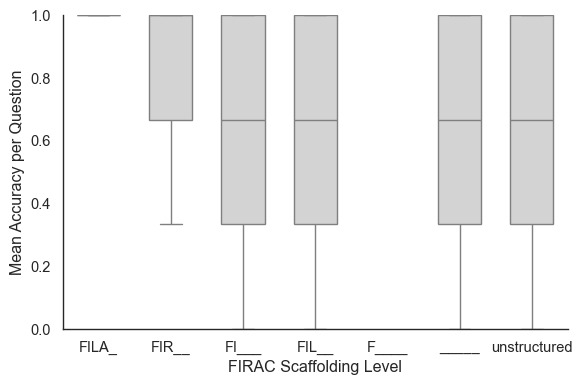

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo ACL
sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.2
)


plt.figure(figsize=(6, 4))

ax = sns.boxplot(
    data=mean_by_question_firac,
    x="firac",
    y="mean_is_correct",
    order=firac_order,
    showfliers=False,
    width=0.6,
    color="lightgray",
    linewidth=1
)

ax.set_xlabel("FIRAC Scaffolding Level")
ax.set_ylabel("Mean Accuracy per Question")
ax.set_ylim(0, 1)

sns.despine()
plt.tight_layout()

plt.savefig(
    "../reports/accuracy_by_firac_boxplot.pdf",
    format="pdf",
    bbox_inches="tight"
)


plt.show()
